In [24]:
import pandas as pd
import numpy as np

# 1) Load
df = pd.read_csv("data.csv", low_memory=False)
print("Shape on load:", df.shape)
print(df.head(3))

# 2) Basic structure & missingness
print("\nMissing (non-zero):")
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))

# 3) Remove exact duplicates
dups = df.duplicated().sum()
df = df.drop_duplicates()
print(f"\nDuplicates removed: {dups}")

# 4) Keep only target + numeric predictors used in analysis
keep_cols = ["MSRP", "Engine HP", "Engine Cylinders", "city mpg", "highway MPG"]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()

# 5) Ensure numeric dtypes, coerce bad strings to NaN
for c in keep_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 6) Target integrity: drop rows with missing MSRP
miss_msrp = df["MSRP"].isna().sum()
df = df.dropna(subset=["MSRP"])
print(f"Rows with missing MSRP removed: {miss_msrp}")

# 7) Impute numeric predictors with median
pred_cols = [c for c in ["Engine HP", "Engine Cylinders", "city mpg", "highway MPG"] if c in df.columns]
for col in pred_cols:
    med = df[col].median()
    df[col] = df[col].fillna(med)

# 8) Outlier report for MSRP
Q1, Q3 = df["MSRP"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = ((df["MSRP"] < lb) | (df["MSRP"] > ub)).sum()
print(f"MSRP outlier count (IQR rule): {outliers} (retained)")

# 9) Final checks
print("\nFinal shape:", df.shape)
print("Nulls after cleaning:\n", df.isna().sum())

# 10) Save modeling table
df.to_csv("cars_cleaned.csv", index=False)
print("Saved: cars_cleaned.csv")

Shape on load: (11914, 16)
  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         Coupe   
1                     Luxury,Performance      Compact   Convertible   
2                Luxury,High-Performance      Compact         Coupe   

   highway MPG  city mpg  Popularity   MSRP  
0           26        19        3916  46135  
1           28    


=== Regression Results ===
                            OLS Regression Results                            
Dep. Variable:                   MSRP   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     2300.
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:34   Log-Likelihood:            -1.3603e+05
No. Observations:               11199   AIC:                         2.721e+05
Df Residuals:                   11194   BIC:                         2.721e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const       

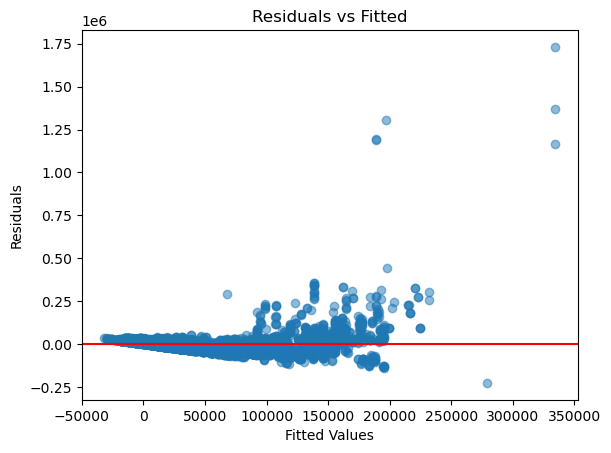


=== ANOVA: MSRP by Engine HP ===
                     df        sum_sq       mean_sq            F  PR(>F)
Q('Engine HP')      1.0  1.839718e+13  1.839718e+13  8581.358833     0.0
Residual        11197.0  2.400474e+13  2.143854e+09          NaN     NaN


In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

df = pd.read_csv("cars_cleaned.csv", low_memory=False)

numeric_features = ["Engine HP", "Engine Cylinders", "city mpg", "highway MPG"]
df = df[numeric_features + ["MSRP"]].apply(pd.to_numeric, errors='coerce').dropna()

X = df[numeric_features]
y = df["MSRP"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print("\n=== Regression Results ===")
print(model.summary())
print("\nAdjusted R-squared:", model.rsquared_adj)

X_no_const = X.drop(columns=["const"])
vif = pd.DataFrame({
    "Feature": X_no_const.columns,
    "VIF": [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
})
print("\n=== Variance Inflation Factor ===")
print(vif)

plt.scatter(model.fittedvalues, model.resid, alpha=0.5)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

anova_model = ols("MSRP ~ Q('Engine HP')", data=df).fit()
anova_results = anova_lm(anova_model)
print("\n=== ANOVA: MSRP by Engine HP ===")
print(anova_results)